In [2]:
import kagglehub
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.formula.api as smf
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression


c:\Users\mason\OneDrive\Desktop\MATH_3310\Final Project\MATH3310_FA_2025_FP2_02_RALLS\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Download latest version
path = kagglehub.dataset_download("ayeshaimran123/social-media-and-mental-health-balance")

print(os.listdir(path))

['Mental_Health_and_Social_Media_Balance_Dataset.csv']


In [4]:
csv_path = os.path.join(path, "Mental_Health_and_Social_Media_Balance_Dataset.csv")

df = pd.read_csv(csv_path)
df

,User_ID,Age,Gender,Daily_Screen_Time(hrs),Sleep_Quality(1-10),Stress_Level(1-10),Days_Without_Social_Media,Exercise_Frequency(week),Social_Media_Platform,Happiness_Index(1-10)
0,U001,44,Male,3.1,7.0,6.0,2.0,5.0,Facebook,10.0
1,U002,30,Other,5.1,7.0,8.0,5.0,3.0,LinkedIn,10.0
2,U003,23,Other,7.4,6.0,7.0,1.0,3.0,YouTube,6.0
3,U004,36,Female,5.7,7.0,8.0,1.0,1.0,TikTok,8.0
4,U005,34,Female,7.0,4.0,7.0,5.0,1.0,X (Twitter),8.0
...,...,...,...,...,...,...,...,...,...,...
495,U496,23,Male,6.9,5.0,7.0,4.0,2.0,X (Twitter),10.0
496,U497,43,Female,5.6,7.0,6.0,5.0,2.0,Facebook,9.0
497,U498,41,Male,7.7,5.0,7.0,2.0,2.0,LinkedIn,8.0
498,U499,23,Male,4.2,9.0,7.0,0.0,2.0,Facebook,9.0


In [5]:
# Explore the dataset
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   User_ID                    500 non-null    object 
 1   Age                        500 non-null    int64  
 2   Gender                     500 non-null    object 
 3   Daily_Screen_Time(hrs)     500 non-null    float64
 4   Sleep_Quality(1-10)        500 non-null    float64
 5   Stress_Level(1-10)         500 non-null    float64
 6   Days_Without_Social_Media  500 non-null    float64
 7   Exercise_Frequency(week)   500 non-null    float64
 8   Social_Media_Platform      500 non-null    object 
 9   Happiness_Index(1-10)      500 non-null    float64
dtypes: float64(6), int64(1), object(3)
memory usage: 39.2+ KB


User_ID                      0
Age                          0
Gender                       0
Daily_Screen_Time(hrs)       0
Sleep_Quality(1-10)          0
Stress_Level(1-10)           0
Days_Without_Social_Media    0
Exercise_Frequency(week)     0
Social_Media_Platform        0
Happiness_Index(1-10)        0
dtype: int64

In [6]:
# define features and target variable
features = df.drop("Happiness_Index(1-10)", axis=1)
target = df["Happiness_Index(1-10)"]

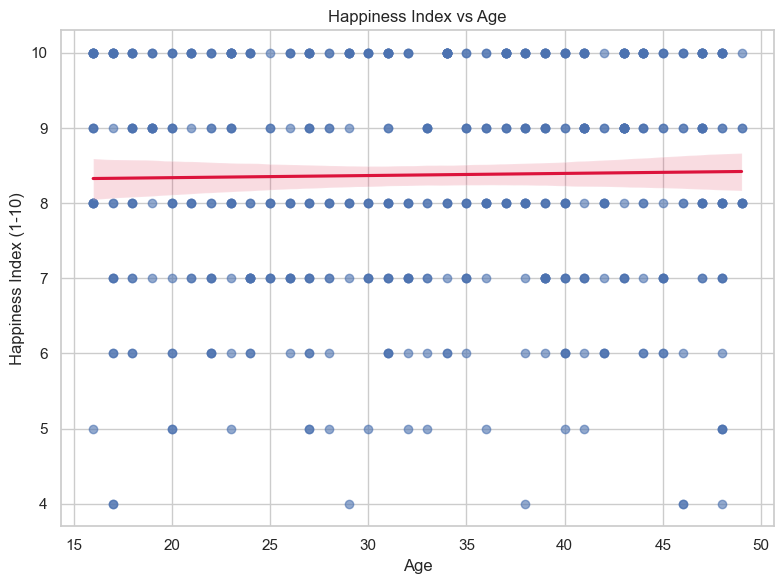

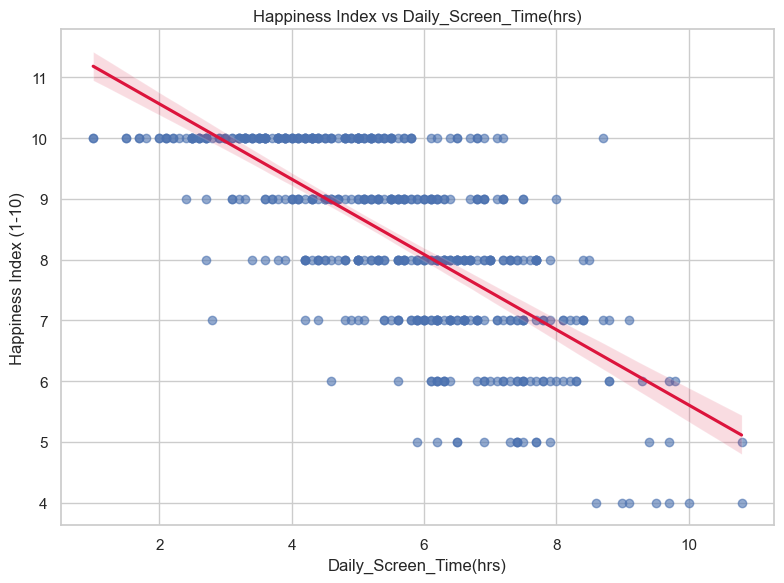

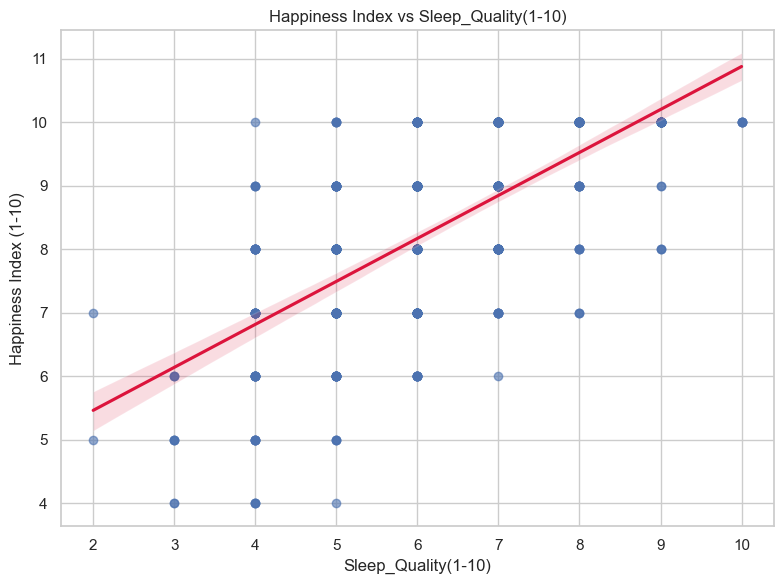

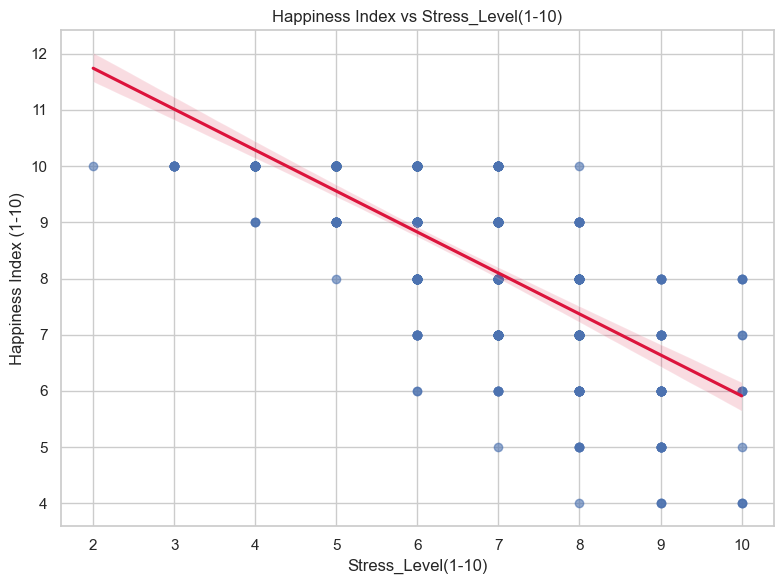

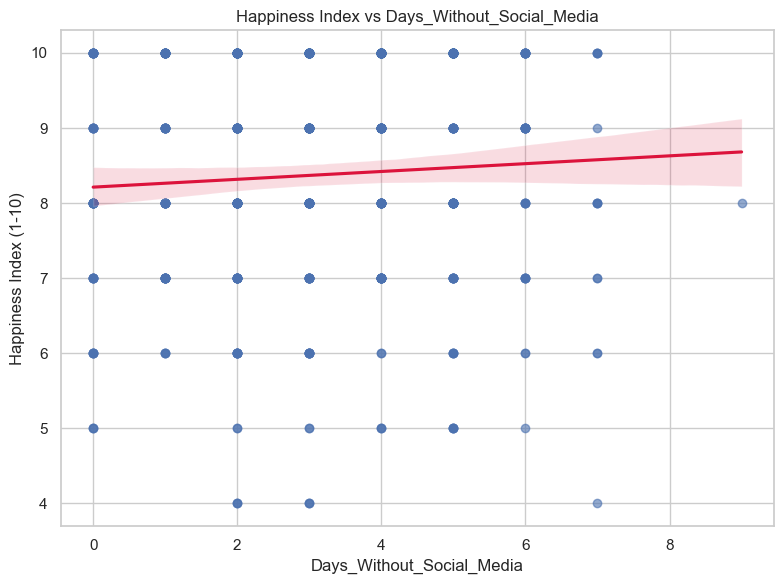

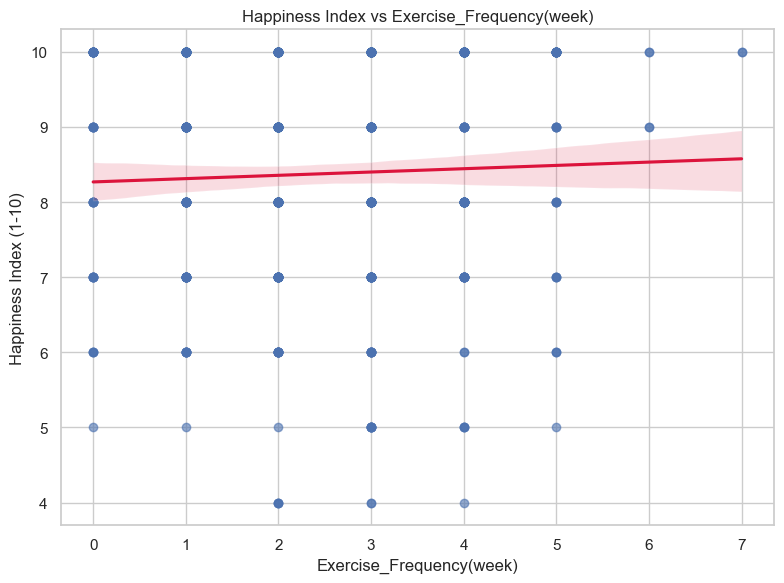

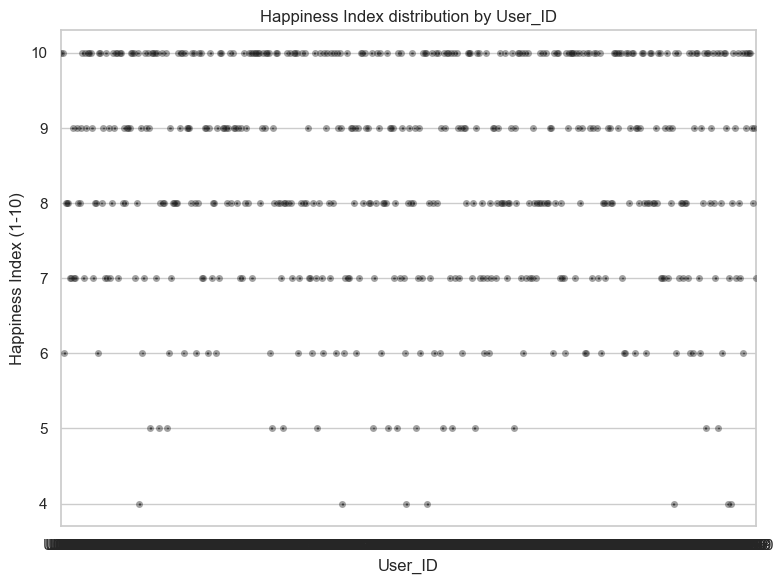

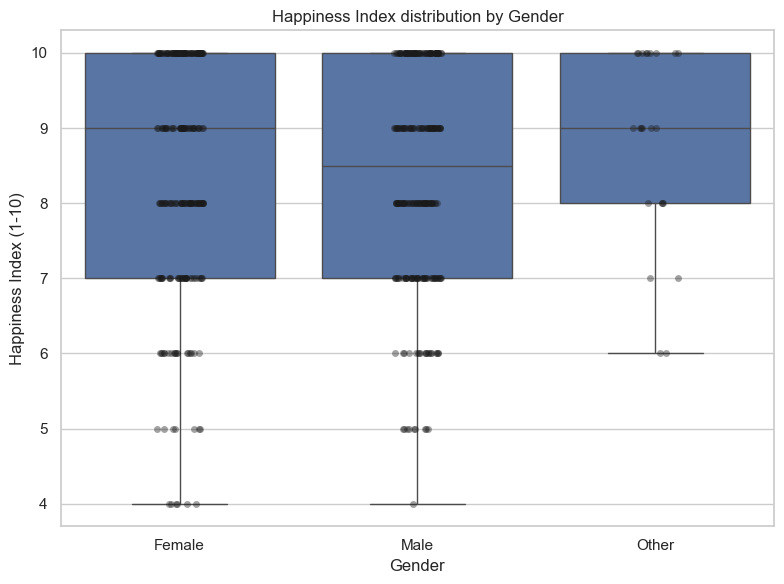

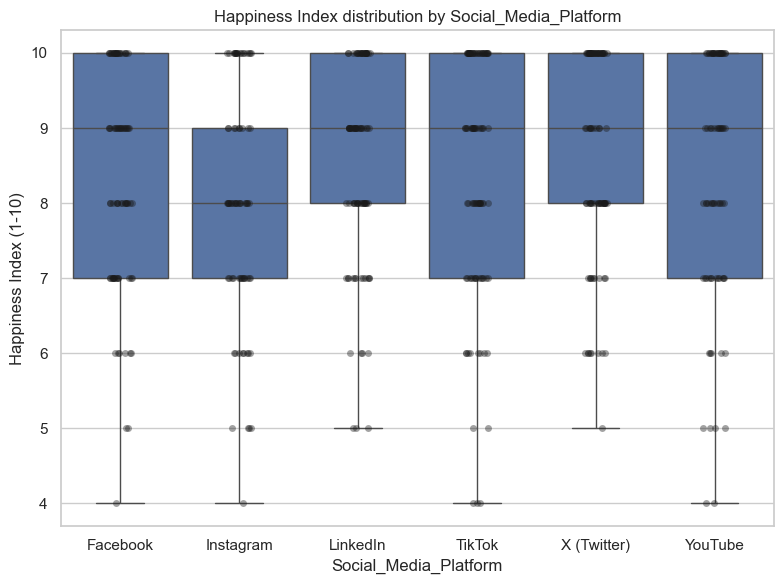

In [7]:
# Robust plotting: numeric -> regplot; categorical -> boxplot + stripplot
sns.set(style='whitegrid')
# Work on a copy and try to coerce numeric-like columns to numeric
features_coerced = features.copy()
for col in features_coerced.columns:
    coerced = pd.to_numeric(features_coerced[col], errors='coerce')
    # Accept coercion if at least half of values (or at least 2) are numeric
    if coerced.notna().sum() >= max(2, int(0.5 * len(coerced))):
        features_coerced[col] = coerced
# Split columns into numeric vs non-numeric
numeric_cols = features_coerced.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in features_coerced.columns if c not in numeric_cols]
# Plot numeric features with regression
for col in numeric_cols:
    plt.figure(figsize=(8, 6))
    sns.regplot(x=features_coerced[col], y=target, scatter_kws={'alpha':0.6}, line_kws={'color':'crimson'})
    plt.title(f'Happiness Index vs {col}')
    plt.xlabel(col)
    plt.ylabel('Happiness Index (1-10)')
    plt.tight_layout()
    plt.show()
# Plot categorical features with boxplot + stripplot
for col in categorical_cols:
    plt.figure(figsize=(8, 6))
    sns.boxplot(x=features_coerced[col].astype('category'), y=target)
    sns.stripplot(x=features_coerced[col].astype('category'), y=target, color='k', alpha=0.4, jitter=True)
    plt.title(f'Happiness Index distribution by {col}')
    plt.xlabel(col)
    plt.ylabel('Happiness Index (1-10)')
    plt.tight_layout()
    plt.show()

In [8]:
# Drop non-numeric columns for correlation analysis
df = df.select_dtypes(include=[np.number]).dropna()

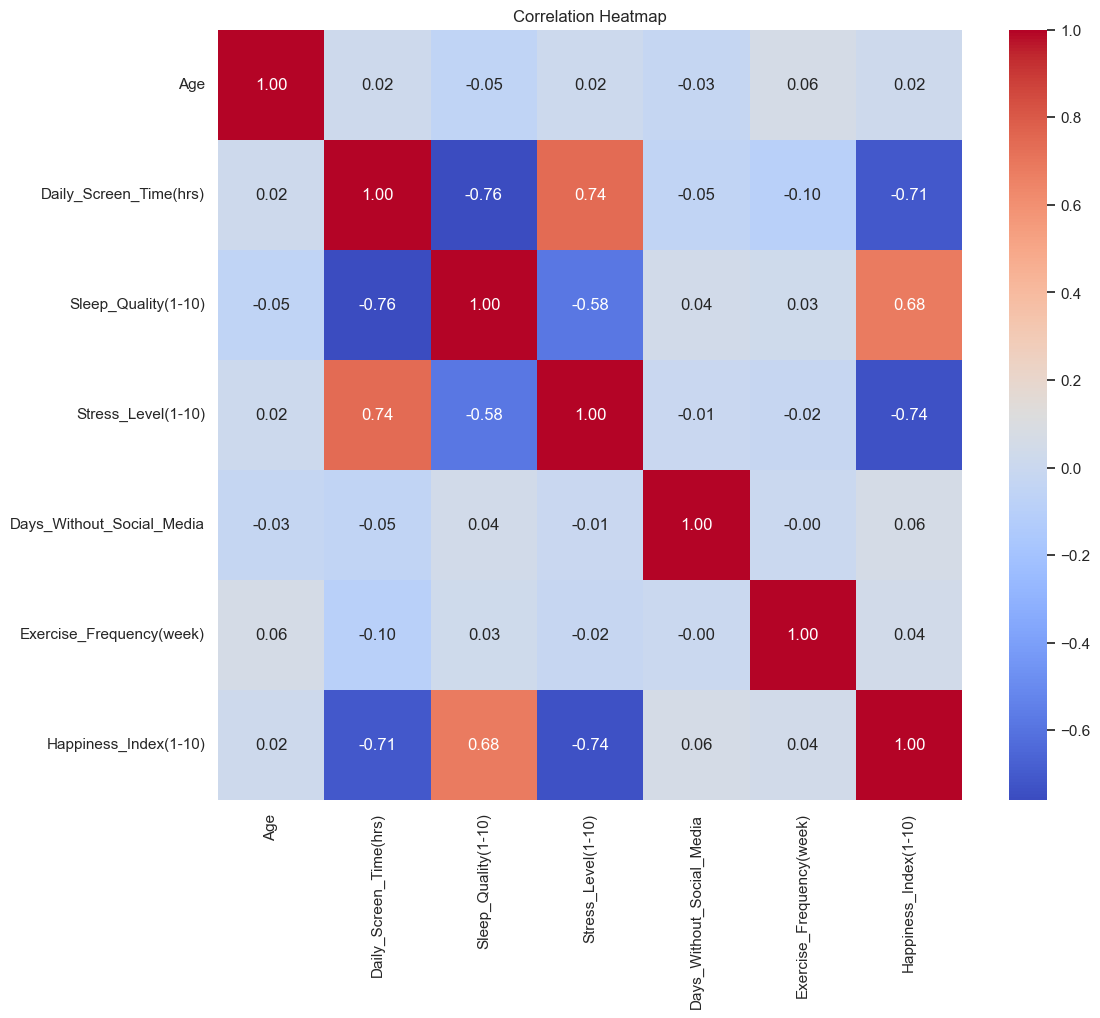

In [9]:
# create a correlation heatmap to visualize relationships between features and target variable
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

High Correlation:

Screen Time -> Stress

Screen Time -> Sleep Quality

Sleep Quality -> Stress

In [10]:
# VIF Analysis to check for multicollinearity
# Select only numeric features to avoid dtype errors
numeric_features = features.select_dtypes(include=[np.number])
vif_matrix = numeric_features
# Center features before VIF
features_centered = vif_matrix - vif_matrix.mean()
vif_data = pd.DataFrame()
vif_data['feature'] = features_centered.columns
vif_data['VIF'] = [variance_inflation_factor(features_centered.values, i) for i in range(features_centered.shape[1])]
vif_data

,feature,VIF
0,Age,1.008261
1,Daily_Screen_Time(hrs),3.515883
2,Sleep_Quality(1-10),2.382862
3,Stress_Level(1-10),2.233106
4,Days_Without_Social_Media,1.004257
5,Exercise_Frequency(week),1.025797


In [11]:
# Add interaction terms
df["screen_c"] = df["Daily_Screen_Time(hrs)"] - df["Daily_Screen_Time(hrs)"].mean()
df["sleep_c"] = df["Sleep_Quality(1-10)"] - df["Sleep_Quality(1-10)"].mean()
df["stress_c"] = df["Stress_Level(1-10)"] - df["Stress_Level(1-10)"].mean()

df["screen_sleep"] = df["screen_c"] * df["sleep_c"]
df["screen_stress"] = df["screen_c"] * df["stress_c"]
df["sleep_stress"] = df["sleep_c"] * df["stress_c"]

In [12]:
df.head()

,Age,Daily_Screen_Time(hrs),Sleep_Quality(1-10),Stress_Level(1-10),Days_Without_Social_Media,Exercise_Frequency(week),Happiness_Index(1-10),screen_c,sleep_c,stress_c,screen_sleep,screen_stress,sleep_stress
0,44,3.1,7.0,6.0,2.0,5.0,10.0,-2.43,0.696,-0.618,-1.69128,1.50174,-0.430128
1,30,5.1,7.0,8.0,5.0,3.0,10.0,-0.43,0.696,1.382,-0.29928,-0.59426,0.961872
2,23,7.4,6.0,7.0,1.0,3.0,6.0,1.87,-0.304,0.382,-0.56848,0.71434,-0.116128
3,36,5.7,7.0,8.0,1.0,1.0,8.0,0.17,0.696,1.382,0.11832,0.23494,0.961872
4,34,7.0,4.0,7.0,5.0,1.0,8.0,1.47,-2.304,0.382,-3.38688,0.56154,-0.880128


In [13]:
# include interaction terms and drop centered terms in features
features = df[["Age", "Daily_Screen_Time(hrs)", "Sleep_Quality(1-10)", "Stress_Level(1-10)", "Days_Without_Social_Media", "Exercise_Frequency(week)","screen_sleep", "screen_stress", "sleep_stress"]]
target = df["Happiness_Index(1-10)"]

In [14]:
# train-test split
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

Feature: Age, Score: 0.006069534327384246
Feature: Daily_Screen_Time(hrs), Score: -0.056313155455022815
Feature: Sleep_Quality(1-10), Score: 0.3479660684042474
Feature: Stress_Level(1-10), Score: -0.47936151033394914
Feature: Days_Without_Social_Media, Score: 0.03209887826375723
Feature: Exercise_Frequency(week), Score: -0.013391551444620616
Feature: screen_sleep, Score: 0.03322333242748189
Feature: screen_stress, Score: -0.03494943367569848
Feature: sleep_stress, Score: 0.019731785553314354


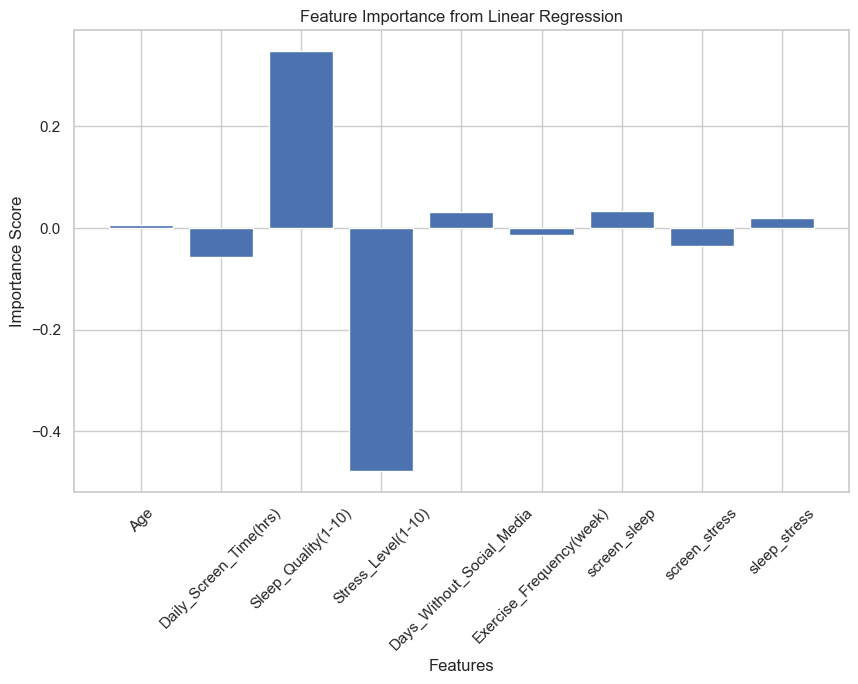

In [15]:
# feature importance using sklearn
model = LinearRegression()
model.fit(X_train, y_train)
importance = model.coef_
for i, v in enumerate(importance):
    print(f'Feature: {X_train.columns[i]}, Score: {v}')

# Plot feature importance with interaction terms
plt.figure(figsize=(10, 6))
plt.bar(X_train.columns, importance)
plt.xlabel('Features')
plt.ylabel('Importance Score')
plt.title('Feature Importance from Linear Regression')
plt.xticks(rotation=45)
plt.show()

**Interpretation**

Higher sleep quality strongly increases happiness

Higher stress level strongly decreases happiness (largest effect in the model)

Higher daily screen time slightly decreases happiness, but with an important nuance: It has interations, so its effect depends on sleep and stress

**Interaction Terms:**

Screen_Sleep (Positive): When sleep quality is good, the negative effects of screen time are reduced

Screen_Stress (Negative): Screen time negatively effects people who already have high stress levels

Sleep_Stress (Positive): Good sleep reduces the negative effects of stress

In [16]:
# Linear regression with interaction terms using statsmodels (fit on training set)
# ensure the model is fit on the training split for evaluation consistency

# Work on a copy of the training dataframe and add target
train_df = X_train.copy()
train_df['Happiness_Index'] = y_train.values

# Patsy/statsmodels formulas require valid Python identifiers.
# Rename any columns that contain spaces, parentheses or other invalid chars.
rename_map = {
	"Happiness_Index(1-10)": "Happiness_Index",
	"Daily_Screen_Time(hrs)": "Daily_Screen_Time_hrs",
	"Sleep_Quality(1-10)": "Sleep_Quality",
	"Stress_Level(1-10)": "Stress_Level",
	"Exercise_Frequency(week)": "Exercise_Frequency_week"
	# other columns (Age, Days_Without_Social_Media, screen_sleep, ...) are already valid
}
train_df = train_df.rename(columns=rename_map)

# Build formula from the renamed dataframe columns (exclude the target)
predictors = [c for c in train_df.columns if c != 'Happiness_Index']
formula = "Happiness_Index ~ " + " + ".join(predictors)

# Fit the OLS model
model = smf.ols(formula=formula, data=train_df).fit()

print(model.summary())


                            OLS Regression Results                            
Dep. Variable:        Happiness_Index   R-squared:                       0.676
Model:                            OLS   Adj. R-squared:                  0.668
Method:                 Least Squares   F-statistic:                     90.38
Date:                Thu, 04 Dec 2025   Prob (F-statistic):           8.89e-90
Time:                        12:38:40   Log-Likelihood:                -509.18
No. Observations:                 400   AIC:                             1038.
Df Residuals:                     390   BIC:                             1078.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

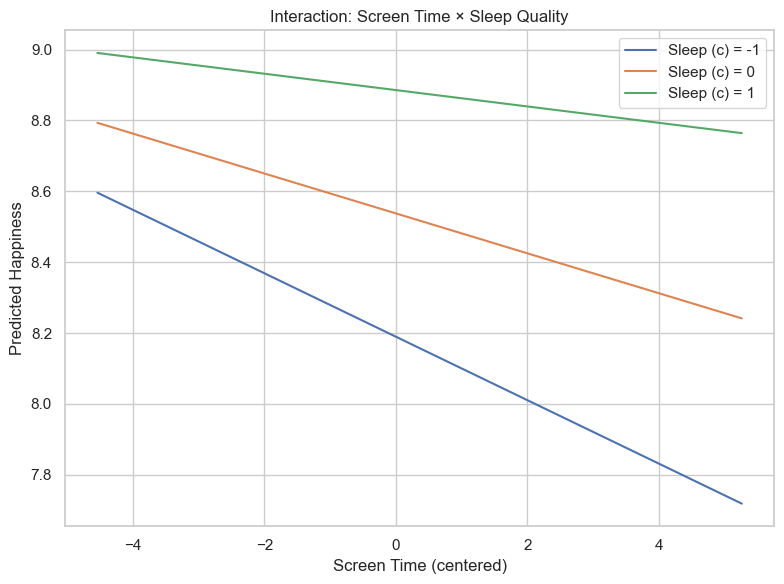

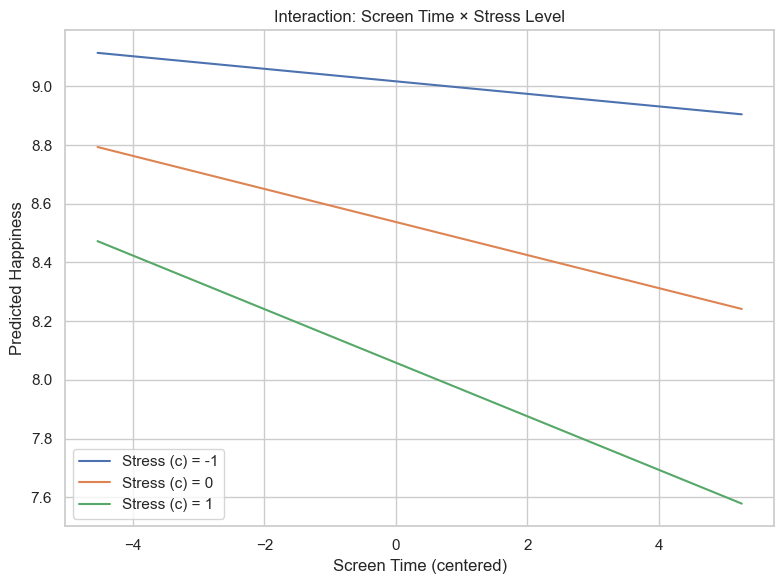

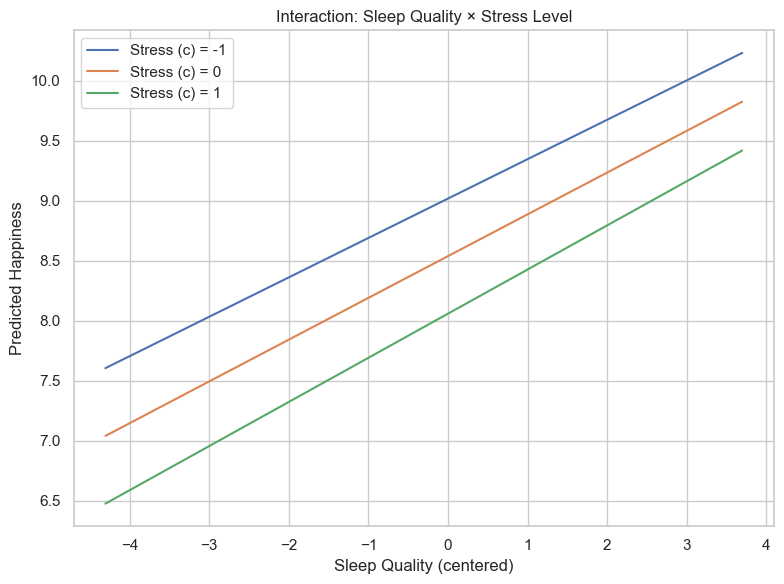

In [17]:
# Interaction effects visualizations
# We compute predictions using the same variable names that were used to fit the statsmodels OLS.
# For predictors not being varied we hold them at their training-set means.

# predictor names used in the statsmodels model (after renaming)
predictors = [c for c in train_df.columns if c != 'Happiness_Index']
means = train_df[predictors].mean()

mean_screen = means['Daily_Screen_Time_hrs']
mean_sleep = means['Sleep_Quality']
mean_stress = means['Stress_Level']
mean_age = means.get('Age', 0)
mean_days = means.get('Days_Without_Social_Media', 0)
mean_exercise = means.get('Exercise_Frequency_week', 0)

# Range of uncentered screen values and corresponding centered values
screen_vals = np.linspace(train_df['Daily_Screen_Time_hrs'].min(), train_df['Daily_Screen_Time_hrs'].max(), 100)
screen_c = screen_vals - mean_screen

# Plot Screen × Sleep interaction (vary screen, show lines for low/avg/high sleep (centered))
sleep_centered_vals = [-1, 0, 1]

plt.figure(figsize=(8, 6))
for s in sleep_centered_vals:
    # sleep value on original scale
    sleep_val = mean_sleep + s
    # start from intercept
    pred = np.full_like(screen_vals, model.params.get('Intercept', 0.0), dtype=float)

    # Add main effects (use model params if present)
    pred += model.params.get('Daily_Screen_Time_hrs', 0.0) * screen_vals
    pred += model.params.get('Sleep_Quality', 0.0) * sleep_val
    pred += model.params.get('Stress_Level', 0.0) * mean_stress
    pred += model.params.get('Age', 0.0) * mean_age
    pred += model.params.get('Days_Without_Social_Media', 0.0) * mean_days
    pred += model.params.get('Exercise_Frequency_week', 0.0) * mean_exercise

    # Add interaction terms. When not varying the interacting counterpart, use its centered value.
    pred += model.params.get('screen_sleep', 0.0) * (screen_c * s)           # screen_c * sleep_c
    pred += model.params.get('screen_stress', 0.0) * (screen_c * 0.0)       # stress at mean -> stress_c ~= 0
    pred += model.params.get('sleep_stress', 0.0) * (s * 0.0)               # stress_c ~= 0

    plt.plot(screen_c, pred, label=f"Sleep (c) = {s}")

plt.xlabel("Screen Time (centered)")
plt.ylabel("Predicted Happiness")
plt.title("Interaction: Screen Time × Sleep Quality")
plt.legend()
plt.tight_layout()
plt.show()

# Plot Screen × Stress interaction (vary screen, show lines for low/avg/high stress (centered))
stress_centered_vals = [-1, 0, 1]

plt.figure(figsize=(8, 6))
for st in stress_centered_vals:
    stress_val = mean_stress + st
    pred = np.full_like(screen_vals, model.params.get('Intercept', 0.0), dtype=float)

    pred += model.params.get('Daily_Screen_Time_hrs', 0.0) * screen_vals
    pred += model.params.get('Sleep_Quality', 0.0) * mean_sleep
    pred += model.params.get('Stress_Level', 0.0) * stress_val
    pred += model.params.get('Age', 0.0) * mean_age
    pred += model.params.get('Days_Without_Social_Media', 0.0) * mean_days
    pred += model.params.get('Exercise_Frequency_week', 0.0) * mean_exercise

    pred += model.params.get('screen_stress', 0.0) * (screen_c * st)        # screen_c * stress_c
    pred += model.params.get('screen_sleep', 0.0) * (screen_c * 0.0)       # sleep_c at mean -> 0
    pred += model.params.get('sleep_stress', 0.0) * (0.0 * st)            # sleep_c at mean -> 0

    plt.plot(screen_c, pred, label=f"Stress (c) = {st}")

plt.xlabel("Screen Time (centered)")
plt.ylabel("Predicted Happiness")
plt.title("Interaction: Screen Time × Stress Level")
plt.legend()
plt.tight_layout()
plt.show()

# Plot Sleep × Stress interaction (vary sleep, show lines for low/avg/high stress (centered))
sleep_vals_uncentered = np.linspace(train_df['Sleep_Quality'].min(), train_df['Sleep_Quality'].max(), 100)
sleep_c_vals = sleep_vals_uncentered - mean_sleep

plt.figure(figsize=(8, 6))
for st in stress_centered_vals:
    stress_val = mean_stress + st
    pred = np.full_like(sleep_vals_uncentered, model.params.get('Intercept', 0.0), dtype=float)

    pred += model.params.get('Daily_Screen_Time_hrs', 0.0) * mean_screen
    pred += model.params.get('Sleep_Quality', 0.0) * sleep_vals_uncentered
    pred += model.params.get('Stress_Level', 0.0) * stress_val
    pred += model.params.get('Age', 0.0) * mean_age
    pred += model.params.get('Days_Without_Social_Media', 0.0) * mean_days
    pred += model.params.get('Exercise_Frequency_week', 0.0) * mean_exercise

    pred += model.params.get('sleep_stress', 0.0) * (sleep_c_vals * st)   # sleep_c * stress_c
    pred += model.params.get('screen_sleep', 0.0) * (0.0 * sleep_c_vals) # screen_c at mean -> 0
    pred += model.params.get('screen_stress', 0.0) * (0.0 * st)         # screen_c at mean -> 0

    plt.plot(sleep_c_vals, pred, label=f"Stress (c) = {st}")

plt.xlabel("Sleep Quality (centered)")
plt.ylabel("Predicted Happiness")
plt.title("Interaction: Sleep Quality × Stress Level")
plt.legend()
plt.tight_layout()
plt.show()

**Interaction Effects Summary**

Three two-way interactions above were examined to understand how screen time, sleep quality, and stress jointly predict happiness.

First, the screen time × sleep quality interaction revealed that people with poor sleep quality experienced a stronger negative relationship between screen time and happiness. In contrast, good sleepers showed a more moderate decline, suggesting that sleep quality may buffer the adverse effects of increased screen time.

Second, the screen time × stress interaction indicated that greater screen time predicted lower happiness for all individuals, but this negative effect was strongest among participants with high stress. High-stress individuals not only reported lower happiness overall but showed a steeper decline as screen time increased.

Finally, the interaction between sleep quality and stress showed that higher sleep quality consistently increased happiness across all stress levels, although individuals experiencing higher stress reported lower happiness overall. The nearly parallel lines suggest that sleep benefits everyone similarly, regardless of stress.

Overall, the interaction patterns highlight that sleep quality and stress meaningfully shape how screen time relates to well-being, with good sleep serving as a protective factor and stress intensifying vulnerability to the negative impacts of screen exposure.

**Model Simplification**

Happiness_Index ~ Sleep_Quality + Stress_Level


In [18]:
# build a simplified linear regression model without interaction terms for comparison
simple_formula = "Happiness_Index ~ Age + Daily_Screen_Time_hrs + Sleep_Quality + Stress_Level + Days_Without_Social_Media + Exercise_Frequency_week"
simple_model = smf.ols(formula=simple_formula, data=train_df).fit()
print(simple_model.summary())

                            OLS Regression Results                            
Dep. Variable:        Happiness_Index   R-squared:                       0.652
Model:                            OLS   Adj. R-squared:                  0.647
Method:                 Least Squares   F-statistic:                     122.8
Date:                Thu, 04 Dec 2025   Prob (F-statistic):           6.19e-87
Time:                        12:38:41   Log-Likelihood:                -523.30
No. Observations:                 400   AIC:                             1061.
Df Residuals:                     393   BIC:                             1089.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

In [19]:
# rebuid the model using only the statistically significant predictors from the full model
significant_formula = "Happiness_Index ~ Sleep_Quality + Stress_Level"
significant_model = smf.ols(formula=significant_formula, data=train_df).fit()
print(significant_model.summary())

                            OLS Regression Results                            
Dep. Variable:        Happiness_Index   R-squared:                       0.647
Model:                            OLS   Adj. R-squared:                  0.645
Method:                 Least Squares   F-statistic:                     363.9
Date:                Thu, 04 Dec 2025   Prob (F-statistic):           1.66e-90
Time:                        12:40:36   Log-Likelihood:                -526.25
No. Observations:                 400   AIC:                             1059.
Df Residuals:                     397   BIC:                             1070.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         9.3297      0.417     22.352

The simplest model explains as much variance as the full model